# Jordan Titanic Data Features
**Author:** Jordan  
**Date:** October 31, 2025 <br>
**Objective:** Data inspection, exploration, and preparation for training/test splits.


## Introduction
This project uses seaborn's Titanic dataset to demonstrate pre-processing of data before splitting for analysis and to compare splitting methods.  We will inspect and clean the data before comparing standard pseudo-random splitting to stratified spliting.

## Imports
First, we import the necessary Python libraries for our analysis. 

In [152]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree


## Section 1. Load and Inspect the Data

Next, we load the Titanic dataset from seaborn and view its head.

In [153]:
titanic_df: pd.DataFrame = sns.load_dataset("titanic")
titanic_df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


## Section 2. Data Exploration and Preparation

### 2.1 Handle Missing Values and Clean Data

We impute missing values for 'age' and 'embark_town' using their median and mode respectively.

In [154]:
median_age = titanic_df["age"].median()
titanic_df["age"] = titanic_df["age"].fillna(median_age)
# 'embark_town' is redundant?
mode_embark = titanic_df["embark_town"].mode()[0]
titanic_df["embark_town"] = titanic_df["embark_town"].fillna(mode_embark)

### 2.2 Feature Engineering

Now, we add the feature 'family_size', number of family members on board, by counting sibsp (number of siblings or spouses on board), parch (number of parents or children on board), and 1 to count the individual. 

In [155]:
titanic_df["family_size"] = titanic_df["sibsp"] + titanic_df["parch"] + 1

Then, we numericaly encode the categorical features 'sex', 'embarked', and 'alone'.

In [156]:
# 'sex' redundant?
titanic_df["sex"] = titanic_df["sex"].map({"male": 0, "female": 1})
# 'embarked' redundant?
titanic_df["embarked"] = titanic_df["embarked"].map({"C": 0, "Q": 1, "S": 2})
titanic_df["alone"] = titanic_df["alone"].astype(int)

## Section 3. Feature Selection and Justification

### 3.1  Choose Features and Target

With classification in mind, we now select input and target features for our model.  We will consider the following three different cases for our models:

Case 1: 
- Input Feature: 'alone'
- Target: 'survived'

Case 2:
- Input Feature: 'age'
- Target: 'survived'

Case 3:
- Input Features: 'age' and 'family_size' 
- Target: 'survived'

### 3.2 Define X (features) and y (target)

In [157]:
# Case 1: Feature = 'alone'
X1 = titanic_df[["alone"]]
y1 = titanic_df["survived"]

# Case 2: Feature = 'age'
X2 = titanic_df[["age"]].dropna()
y2 = titanic_df.loc[X2.index, "survived"]

# Case 3: Features = 'age' + 'family_size'
X3 = titanic_df[["age", "family_size"]].dropna()
y3 = titanic_df.loc[X3.index, "survived"]

Reflection 3:

- Why are these features selected?
- Are there features that are likely to be highly predictive of survival?

## Section 4. Train a Classification Model (Decision Tree)
### 4.1 Split the Data

First, we split our data for each case, using a random stratified shuffle split to ensure that both the training and test sets have a similar proportion of each class of our target feature.

In [158]:
# Case 1: Feature = 'alone'
splitter1 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=123)

for train_idx1, test_idx1 in splitter1.split(X1, y1):
    X1_train = X1.iloc[train_idx1]
    X1_test  = X1.iloc[test_idx1]
    y1_train = y1.iloc[train_idx1]
    y1_test  = y1.iloc[test_idx1]

print("Case 1 - 'alone':")
print("Train size:", len(X1_train), "| Test size:", len(X1_test))

Case 1 - 'alone':
Train size: 712 | Test size: 179


In [159]:
# Case 2: Feature = 'age'
splitter2 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=123)

for train_idx2, test_idx2 in splitter2.split(X2, y2):
    X2_train = X2.iloc[train_idx2]
    X2_test  = X2.iloc[test_idx2]
    y2_train = y2.iloc[train_idx2]
    y2_test  = y2.iloc[test_idx2]

print("Case 2 - 'age':")
print("Train size:", len(X2_train), "| Test size:", len(X2_test))

Case 2 - 'age':
Train size: 712 | Test size: 179


In [160]:
# Case 3: Features = 'age' + 'family_size'
splitter3 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=123)

for train_idx3, test_idx3 in splitter3.split(X3, y3):
    X3_train = X3.iloc[train_idx3]
    X3_test  = X3.iloc[test_idx3]
    y3_train = y3.iloc[train_idx3]
    y3_test  = y3.iloc[test_idx3]

print("Case 3 - 'age' + 'family_size':")
print("Train size:", len(X3_train), "| Test size:", len(X3_test))

Case 3 - 'age' + 'family_size':
Train size: 712 | Test size: 179


### 4.2 Create and Train Model (Decision Tree)

Now, we create and train a decision tree model with no random initializer argument.

In [161]:
# CASE 1: Decision Tree using 'alone'
tree_model1 = DecisionTreeClassifier()
tree_model1.fit(X1_train, y1_train)

# CASE 2: Decision Tree using 'age'
tree_model2 = DecisionTreeClassifier()
tree_model2.fit(X2_train, y2_train)

# CASE 3: Decision Tree using 'age' and 'family_size'
tree_model3 = DecisionTreeClassifier()
tree_model3.fit(X3_train, y3_train);

### 4.3 Predict and Evaluate Model Performance

At this stage, we predict and evaluate all three cases.

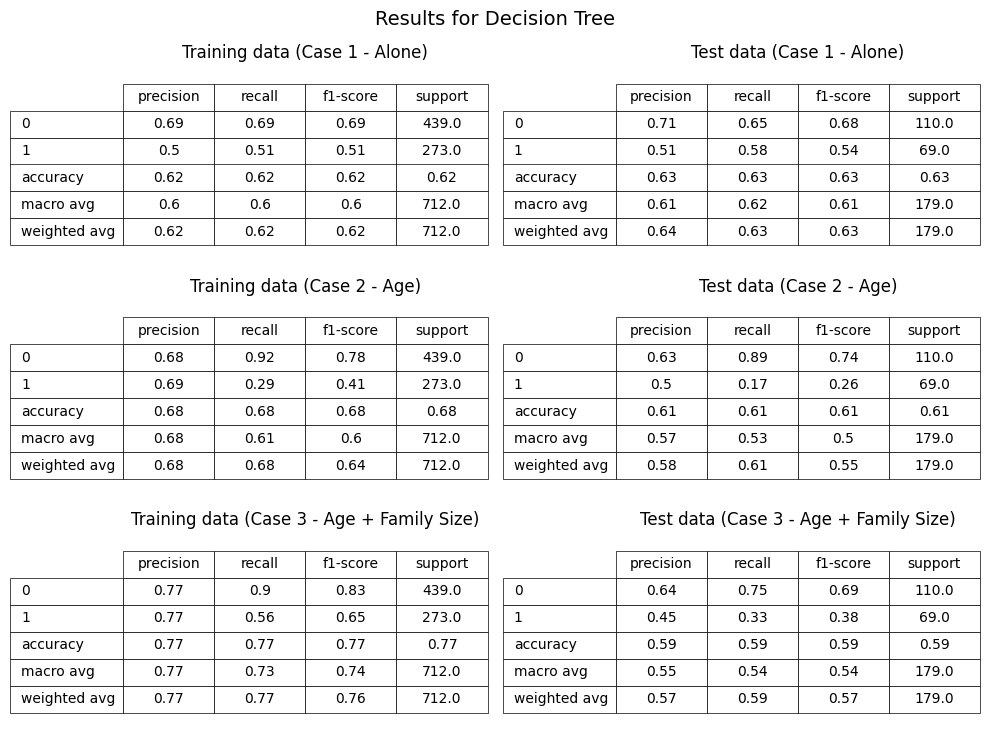

In [162]:
# Case 1: Feature = 'alone'
y1_pred = tree_model1.predict(X1_train)
y1_test_pred = tree_model1.predict(X1_test)

# Case 2: Feature = 'age'
y2_pred = tree_model2.predict(X2_train)
y2_test_pred = tree_model2.predict(X2_test)

# Case 3: Features = 'age' + 'family_size'
y3_pred = tree_model3.predict(X3_train)
y3_test_pred = tree_model3.predict(X3_test)

tree_dict1: dict = {
    "Case 1 - Alone": ((y1_train, y1_pred), (y1_test, y1_test_pred)),
    "Case 2 - Age": ((y2_train, y2_pred), (y2_test, y2_test_pred)),
    "Case 3 - Age + Family Size": ((y3_train, y3_pred), (y3_test, y3_test_pred))
}
flat_tree = ((case, y_t, y_p) for case, data in tree_dict1.items() for y_t, y_p in data)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10,7.5))

for index, (ax, (case, y_t, y_p)) in enumerate(zip(axes.flatten(), flat_tree, strict=True)):

    report_dict = classification_report(y_t, y_p, output_dict=True)
    report_df = pd.DataFrame(report_dict).T.round(2)
    table = ax.table(cellText=report_df.values, colLabels=report_df.columns,
                     rowLabels=report_df.index, loc="center", cellLoc="center")
    ax.axis("off")
    ax.set_title(f"{"Training" if index % 2 == 0  else "Test"} data ({case})")
    table.scale(1,1.4)
    for cell in table.get_celld().values():
        cell.set_linewidth(0.5)

fig.suptitle("Results for Decision Tree", size=14)
plt.tight_layout()
plt.show()
fig.savefig("tree_classification_all_cases.png")

### 4.4 Report Confusion Matrix (as a heatmap)

We then proceed to plot a confusion matrix for all cases.

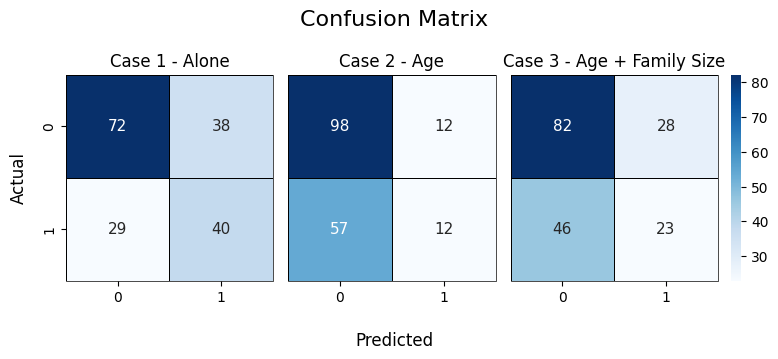

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(8,3.5), gridspec_kw={"width_ratios": [1, 1, 1.25]})

for ax, (case, (_, (y_test, y_test_pred))) in zip(axes, tree_dict1.items(), strict=True):
    cm = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(cm, annot=True, cmap="Blues", ax=ax, cbar=ax is axes[-1],
                annot_kws={"size": 11}, linewidths=.5, linecolor="black")
    ax.patch.set_edgecolor("black")
    ax.patch.set_linewidth(0.5)
    ax.set(title=f"{case}")

for ax in axes[1:]: ax.set( yticks=[], ylabel="")  # noqa: E701
fig.suptitle("Confusion Matrix", size=16)
fig.supxlabel("Predicted")
fig.supylabel("Actual")
plt.tight_layout()
plt.show()

### 4.5 Report Decision Tree Plot

Finally, we plot the decision tree model for each case.

In [176]:
tree_dict2: dict = {
    "Case 1: Alone": (tree_model1, X1),
    "Case 2: Age": (tree_model2, X2),
    "Case 3: Age + Family Size": (tree_model3, X3)
}
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(100,90))

for ax, (case, (model, feature)) in zip(axes, tree_dict2.items(), strict=True):
    plot_tree(model, feature_names=feature.columns.tolist(), ax=ax,
              class_names=["Not Survived", "Survived"], filled=True)
    ax.set_title(f"Decision Tree - {case}", size=70)

plt.tight_layout()
plt.show()
fig.savefig("tree_plot_all_cases.png")

### Reflection 4:
- How well did the different cases perform?
- Are there any surprising results?
- Which inputs worked better? 

## Section 5. Compare Alternative Models (SVC, NN)


### 5.1 Train and Evaluate Model (SVC)

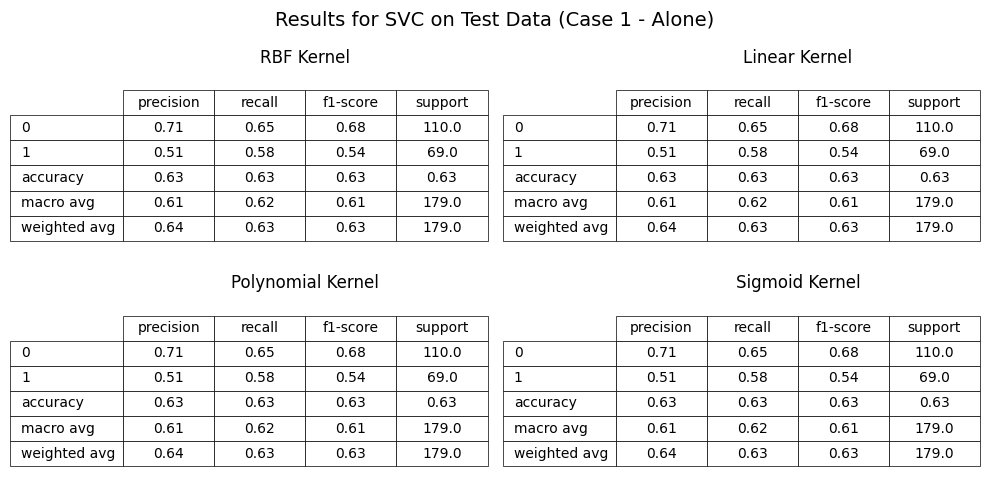

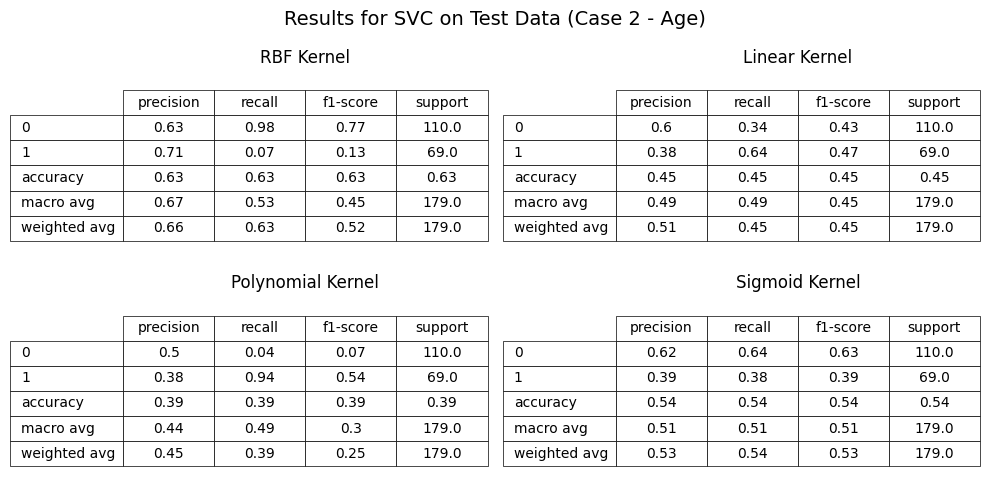

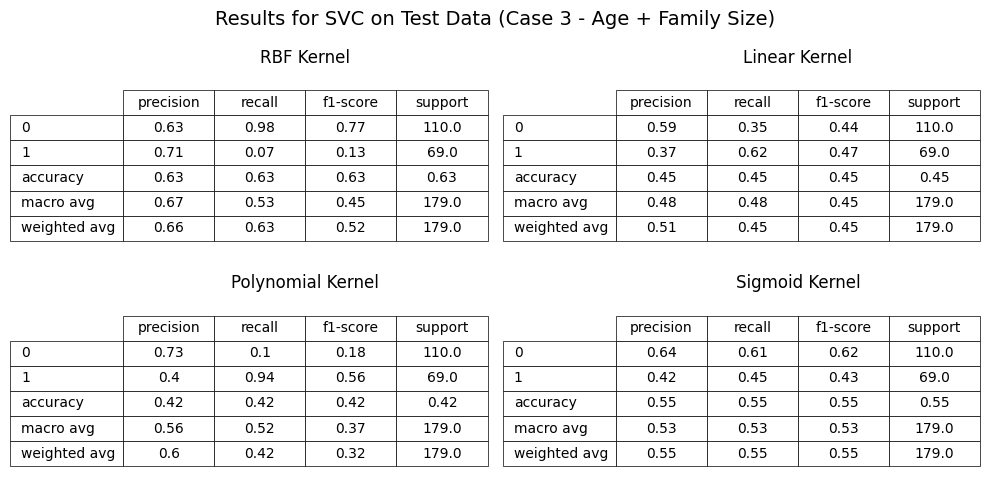

In [ ]:
# CASE 1: SVC using 'alone'
svc_dict1: dict = {
    "RBF": {"kernel": "rbf"},
    "Linear": {"kernel": "linear"},
    "Polynomial": {"kernel": "poly", "degree": 3},
    "Sigmoid": {"kernel": "sigmoid"}
}
# CASE 2: SVC using 'age'
svc_dict2: dict = {
    "RBF": {"kernel": "rbf"},
    "Linear": {"kernel": "linear", "class_weight": "balanced"},
    "Polynomial": {"kernel": "poly", "degree": 3, "class_weight": "balanced"},
    "Sigmoid": {"kernel": "sigmoid"}
}
# CASE 3: SVC using 'age' + 'family_size'
svc_dict3: dict = {
    "RBF": {"kernel": "rbf"},
    "Linear": {"kernel": "linear", "C": 0.01, "class_weight": "balanced"},
    "Polynomial": {"kernel": "poly", "degree": 3, "C": 521.4, "class_weight": "balanced"},
    "Sigmoid": {"kernel": "sigmoid"}
}
case_train_test_svc: dict = {
    "Case 1 - Alone": ((X1_train, X1_test, y1_train, y1_test), svc_dict1),
    "Case 2 - Age": ((X2_train, X2_test, y2_train, y2_test), svc_dict2),
    "Case 3 - Age + Family Size": ((X3_train, X3_test, y3_train, y3_test), svc_dict3)
}

for case, ((X_train, X_test, y_train, y_test), svc_dict) in case_train_test_svc.items():

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10,5))

    for ax, (test, parameters) in zip(axes.flatten(), svc_dict.items(), strict=True):

        svc_model = SVC(**parameters)
        svc_model.fit(X_train, y_train)
        y_svc_pred = svc_model.predict(X_test)
        report_dict = classification_report(y_test, y_svc_pred, output_dict=True)
        report_df = pd.DataFrame(report_dict).T.round(2)
        table = ax.table(cellText=report_df.values, colLabels=report_df.columns,
                     rowLabels=report_df.index, loc="center", cellLoc="center")
        ax.axis("off")
        ax.set_title(f"{test} Kernel")
        table.scale(1,1.4)
        for cell in table.get_celld().values():
            cell.set_linewidth(0.5)

    fig.suptitle(f"Results for SVC on Test Data ({case})", size=14)
    plt.tight_layout()
    plt.show()
    save_str = case.replace("-","_").replace("+", "_").replace(" ", "").lower()
    fig.savefig(f"svc_classification_{save_str}.png")


In [166]:
scaler = StandardScaler()
X3_train_scaled = scaler.fit_transform(X3_train)
X3_test_scaled = scaler.transform(X3_test)

C_range = np.logspace(-4, 3, 100)
param_grid = {"C": C_range}

grid_search = GridSearchCV(
    estimator=SVC(kernel="poly", class_weight="balanced", random_state=42, degree=3),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X3_train, y3_train)

print(f"Best C value found: {grid_search.best_params_['C']}")
print(f"Best F1 Score: {grid_search.best_score_}")

best_linear_model = grid_search.best_estimator_
y_pred_best = best_linear_model.predict(X3_test)
print(classification_report(y3_test, y_pred_best))

Best C value found: 521.4008287999684
Best F1 Score: 0.3938530604399932
              precision    recall  f1-score   support

           0       0.73      0.10      0.18       110
           1       0.40      0.94      0.56        69

    accuracy                           0.42       179
   macro avg       0.56      0.52      0.37       179
weighted avg       0.60      0.42      0.32       179



### Visualize Support Vectors (1D Case 1 and 2D Case 3)

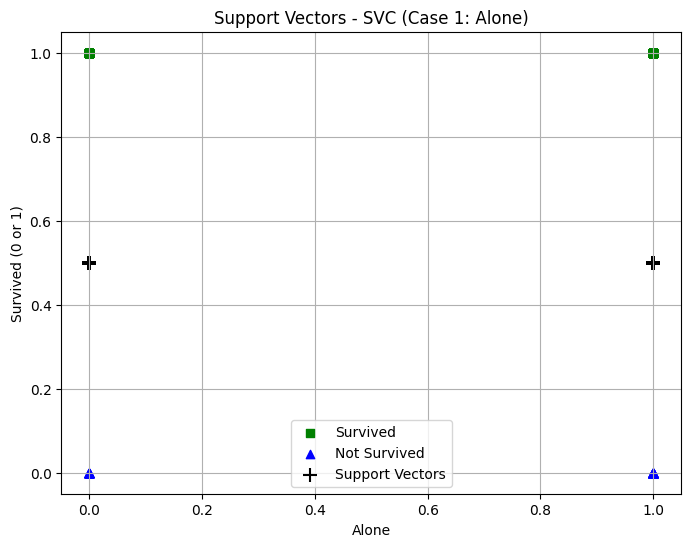

In [167]:
# Visualize support vectors for Case 1 (feature = 'alone')
svc_model1 = SVC(**svc_dict1["RBF"])
svc_model1.fit(X1_train, y1_train)
# Create groups based on survival
survived_alone = X1_test.loc[y1_test == 1, "alone"]
not_survived_alone = X1_test.loc[y1_test == 0, "alone"]

# Create scatter plot for survived and not survived
plt.figure(figsize=(8, 6))

plt.scatter(survived_alone, y1_test.loc[y1_test == 1], c="green", marker="s", label="Survived")
plt.scatter(not_survived_alone, y1_test.loc[y1_test == 0], c="blue", marker="^", label="Not Survived")

# Overlay support vectors
# Check if the model has support_vectors_ (it may not if it failed to converge)
if hasattr(svc_model1, "support_vectors_"):
    # Get the X-values of the support vectors (only one feature in Case 1
    support_x = svc_model1.support_vectors_[:, 0]  # First feature (alone)
    # Plot them using a fixed Y-value (0.5) to place them between classes visually
    # We use a larger size (s=100) and a plus symbol to make them stand out
    plt.scatter(support_x, [0.5] * len(support_x), c="black", marker="+", s=100, label="Support Vectors")

# Add labels and legend
plt.gca().set(xlabel="Alone", ylabel="Survived (0 or 1)", title="Support Vectors - SVC (Case 1: Alone)")
plt.legend()
plt.grid(True)
plt.show()

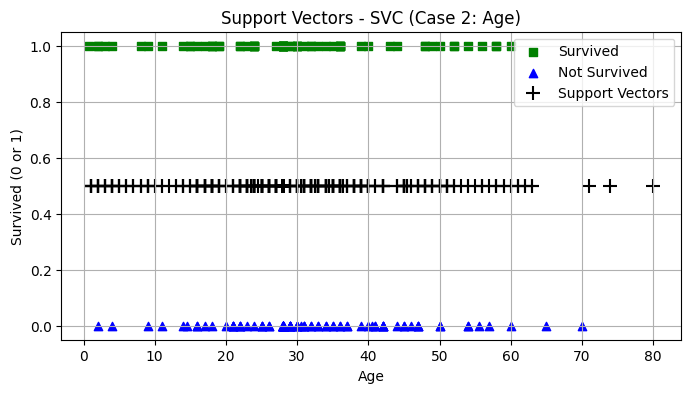

In [168]:
# Visualize support vectors for Case 1 (feature = 'age')
svc_model2 = SVC(**svc_dict2["RBF"])
svc_model2.fit(X2_train, y2_train)
# Create groups based on survival
survived_alone = X2_test.loc[y2_test == 1, "age"]
not_survived_alone = X2_test.loc[y2_test == 0, "age"]

# Create scatter plot for survived and not survived
plt.figure(figsize=(8, 4))
plt.scatter(survived_alone, y2_test.loc[y2_test == 1], c="green", marker="s", label="Survived")
plt.scatter(not_survived_alone, y2_test.loc[y2_test == 0], c="blue", marker="^", label="Not Survived")

# Overlay support vectors
# Check if the model has support_vectors_ (it may not if it failed to converge)
if hasattr(svc_model2, "support_vectors_"):
    # Get the X-values of the support vectors (only one feature in Case 1
    support_x = svc_model2.support_vectors_[:, 0]  # First feature (alone)
    # Plot them using a fixed Y-value (0.5) to place them between classes visually
    # We use a larger size (s=100) and a plus symbol to make them stand out
    plt.scatter(support_x, [0.5] * len(support_x), c="black", marker="+", s=100, label="Support Vectors")

# Add labels and legend
plt.gca().set(xlabel="Age", ylabel="Survived (0 or 1)", title="Support Vectors - SVC (Case 2: Age)")
plt.legend()
plt.grid(True)
plt.show()

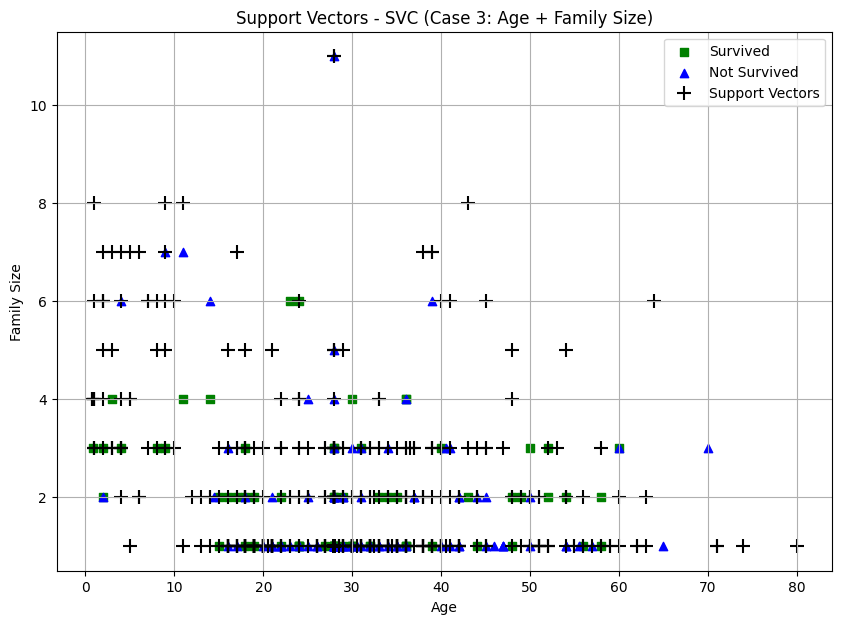

In [169]:
# Visualize support vectors for Case 3 (features = 'age', 'family_size') - more interesting (two dimensional)
svc_model3 = SVC(**svc_dict3["RBF"])
svc_model3.fit(X3_train, y3_train)
# Create groups based on survival
survived = X3_test[y3_test == 1]
not_survived = X3_test[y3_test == 0]

# Create scatter plot
plt.figure(figsize=(10, 7))

# Plot survived (yellow squares)
plt.scatter(survived["age"], survived["family_size"],
            c="green", marker="s", label="Survived")

# Plot not survived (cyan triangles)
plt.scatter(not_survived["age"], not_survived["family_size"],
            c="blue", marker="^", label="Not Survived")

# Overlay support vectors
if hasattr(svc_model3, "support_vectors_"):
    support_vectors = svc_model3.support_vectors_
    plt.scatter(support_vectors[:, 0], support_vectors[:, 1],
                c="black", marker="+", s=100, label="Support Vectors")

# Add labels, title, and legend
plt.gca().set(xlabel="Age", ylabel="Family Size",
              title="Support Vectors - SVC (Case 3: Age + Family Size)")
plt.legend()
plt.grid(True)
plt.show()

### 5.3 Train and Evaluate Model (Neural Network on Case 3)

Now, we'll train a Neural Network (Multi-Layer Perceptron) classifier using age and family_size as input features. This is the most informative case and gives us two continuous features to help the network learn patterns and relationships.

In [170]:
# Train NN for Case 3 (age + family_size)
nn_model3 = MLPClassifier(
    hidden_layer_sizes=(50, 25, 10),
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)
nn_model3.fit(X3_train, y3_train)
# Predict on test data (Case 3)
y3_nn_pred = nn_model3.predict(X3_test)

# Print classification report
print("Results for Neural Network on test data (Case 3 - age + family_size):")
print(classification_report(y3_test, y3_nn_pred))

Results for Neural Network on test data (Case 3 - age + family_size):
              precision    recall  f1-score   support

           0       0.69      0.83      0.75       110
           1       0.60      0.41      0.48        69

    accuracy                           0.66       179
   macro avg       0.64      0.62      0.62       179
weighted avg       0.65      0.66      0.65       179



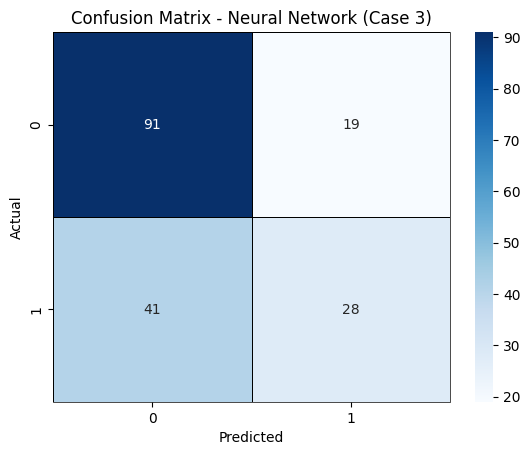

In [171]:
# Create confusion matrix
cm_nn3 = confusion_matrix(y3_test, y3_nn_pred)

# Plot heatmap
fig = sns.heatmap(cm_nn3, annot=True, cmap="Blues",
            linewidths=.5, linecolor="black")
fig.patch.set_edgecolor("black")
fig.patch.set_linewidth(0.5)
plt.gca().set(xlabel="Predicted", ylabel="Actual", title="Confusion Matrix - Neural Network (Case 3)")
plt.show()

5.4 Visualize (Neural Network on Case 3)

c:\Repos\applied-ml-jordan\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


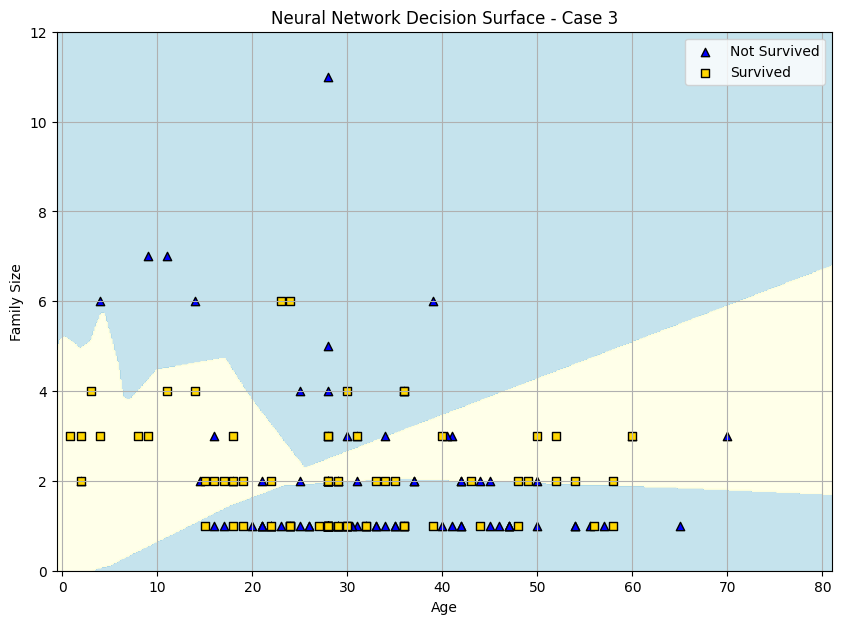

In [172]:
# Get the range of our two features - use padding to enhance appearance

padding = 1
x_min, x_max = X3["age"].min() - padding, X3["age"].max() + padding
y_min, y_max = X3["family_size"].min() - padding, X3["family_size"].max() + padding

# Create a meshgrid (all combinations of age and family_size)

# A grid of values covering the entire input space
# np.linspace(start, stop, num) generates evenly spaced values (like a ruler)
# Here, we create 500 points between min and max for each axis
# np.meshgrid creates a coordinate grid from the two arrays

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                                    np.linspace(y_min, y_max, 500))

# Flatten the grid arrays and prepare them for prediction
# np.c_ stacks the flattened xx and yy into coordinate pairs
# .ravel() flattens a 2D array into 1D (required by the model for prediction)

Z = nn_model3.predict(np.c_[xx.ravel(), yy.ravel()])

# Reshape the predicted results to match the original 2D grid shape
Z = Z.reshape(xx.shape)

# Plot the decision surface (background) showing predicted survival zones

 # Blue for 0, yellow for 1 - change this up as you like
plt.figure(figsize=(10, 7))
cmap_background = ListedColormap(["lightblue", "lightyellow"])

plt.contourf(xx, yy, Z, cmap=cmap_background, alpha=0.7)

# Overlay the actual test data points for visual comparison

# Plot passengers who did NOT survive (0) as blue triangles
plt.scatter(X3_test["age"][y3_test == 0],
            X3_test["family_size"][y3_test == 0],
            c="blue", marker="^", edgecolor="k", label="Not Survived")

# Plot passengers who DID survive (1) as gold squares
plt.scatter(X3_test["age"][y3_test == 1],
            X3_test["family_size"][y3_test == 1],
            c="gold", marker="s", edgecolor="k", label="Survived")

# Add axis labels, title, legend, and grid
plt.gca().set(xlabel="Age", ylabel="Family Size", title="Neural Network Decision Surface - Case 3")
plt.legend()
plt.grid(True)
plt.show()

### Reflection 5:
- How well did each of these new models/cases perform?
- Are there any surprising results or insights?
- Why might one model outperform the others?

## Section 6. Final Thoughts & Insights

- Section 6. Final Thoughts & Insights
- Summarize findings - important: use a table or other device to summarize your findings
- Discuss challenges faced
- Next steps to gain more insights and/or to explore classification models